In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, skew

#  Quick View

In [2]:
pd.set_option('display.max_columns',None)

In [3]:
train = pd.read_csv('AmesHousing.csv')
train.columns = train.columns.str.replace(' ', '').str.replace('/', '')
train = train.drop('PID',axis=1).rename(columns={'Order':'Id'})
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,1Fam,SLvl,6,6,1984,1984,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,TA,TA,Av,GLQ,819.0,Unf,0.0,184.0,1003.0,GasA,TA,Y,SBrkr,1003,0,0,1003,1.0,0.0,1,0,3,1,TA,6,Typ,0,NaN,Detchd,1984.0,Unf,2.0,588.0,TA,TA,Y,120,0,0,0,0,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1983,1983,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,TA,TA,CBlock,Gd,TA,Av,BLQ,301.0,ALQ,324.0,239.0,864.0,GasA,TA,Y,SBrkr,902,0,0,902,1.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1983.0,Unf,2.0,484.0,TA,TA,Y,164,0,0,0,0,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,No

In [4]:
train.shape

(2930, 81)

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2930 non-null   int64  
 1   MSSubClass     2930 non-null   int64  
 2   MSZoning       2930 non-null   str    
 3   LotFrontage    2440 non-null   float64
 4   LotArea        2930 non-null   int64  
 5   Street         2930 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2930 non-null   str    
 8   LandContour    2930 non-null   str    
 9   Utilities      2930 non-null   str    
 10  LotConfig      2930 non-null   str    
 11  LandSlope      2930 non-null   str    
 12  Neighborhood   2930 non-null   str    
 13  Condition1     2930 non-null   str    
 14  Condition2     2930 non-null   str    
 15  BldgType       2930 non-null   str    
 16  HouseStyle     2930 non-null   str    
 17  OverallQual    2930 non-null   int64  
 18  OverallCond    2930

In [6]:
test = pd.read_csv('test.csv')
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,Hd

In [7]:
test.shape

(1459, 80)

In [8]:
train['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

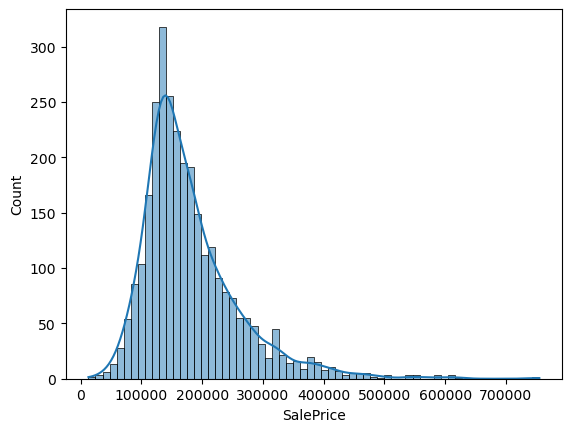

In [9]:
sns.histplot(train['SalePrice'],kde =True)

In [10]:
# skewness: measure skew of a distribution, positive is left-skew, negative is right-skew, >>0 more skew, non-normality
# In literature, acceptable values for skewness are between -0.5 and 0.5 while -2 and 2 for Kurtosis
print("Skewness: %f" % train['SalePrice'].skew())
# kurtosis: thickeness of tail of a distribution -> measure outlier, >>0 more outlier, non-noramlity
print("Kurtosis: %f" % train['SalePrice'].kurt())

Skewness: 1.743500
Kurtosis: 5.118900


<Axes: xlabel='SalePrice', ylabel='Count'>

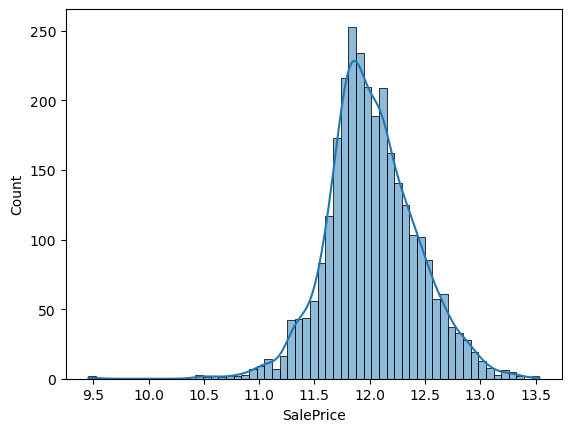

In [11]:
train['SalePrice'] = np.log1p(train['SalePrice'])
sns.histplot(train['SalePrice'],kde =True)

In [12]:
print("Skewness: %f" % train['SalePrice'].skew())
print("Kurtosis: %f" % train['SalePrice'].kurt())

Skewness: -0.014773
Kurtosis: 1.513818


# Relationship

<Axes: >

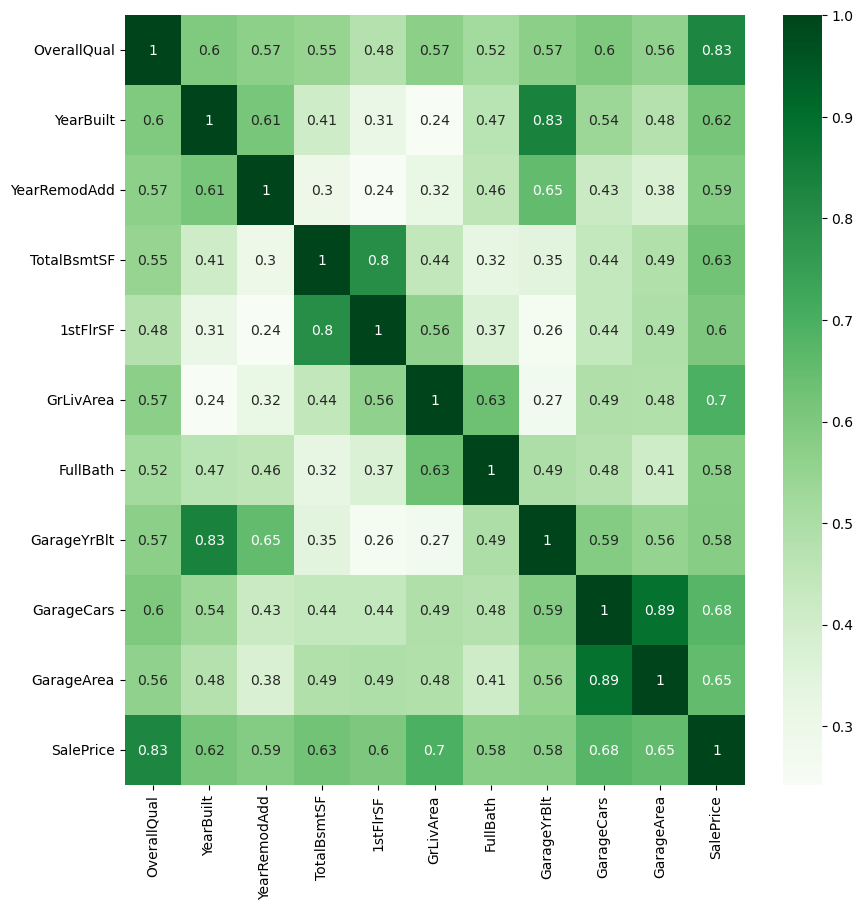

In [13]:
corr = train.select_dtypes(['int64','float64']).corr()
highest_corr_features = corr.index[abs(corr["SalePrice"]) > 0.5]
plt.figure(figsize=(10,10))
sns.heatmap(train[highest_corr_features].corr(),annot=True,cmap="Greens")

In [14]:
corr["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.825645
GrLivArea        0.695863
GarageCars       0.675318
GarageArea       0.651132
TotalBsmtSF      0.625099
YearBuilt        0.615485
1stFlrSF         0.602629
YearRemodAdd     0.586153
GarageYrBlt      0.580502
FullBath         0.577335
TotRmsAbvGrd     0.492580
Fireplaces       0.488945
MasVnrArea       0.448613
BsmtFinSF1       0.410801
LotFrontage      0.350224
WoodDeckSF       0.333320
OpenPorchSF      0.319938
HalfBath         0.305921
BsmtFullBath     0.275249
2ndFlrSF         0.274692
LotArea          0.255032
BsmtUnfSF        0.193790
BedroomAbvGr     0.180503
ScreenPorch      0.110425
PoolArea         0.054403
3SsnPorch        0.040248
MoSold           0.038960
BsmtFinSF2       0.018332
MiscVal         -0.008718
BsmtHalfBath    -0.020954
Id              -0.028814
YrSold          -0.033131
LowQualFinSF    -0.044842
OverallCond     -0.048294
MSSubClass      -0.070744
KitchenAbvGr    -0.128213
EnclosedPorch   -0.142486
Name: SalePr

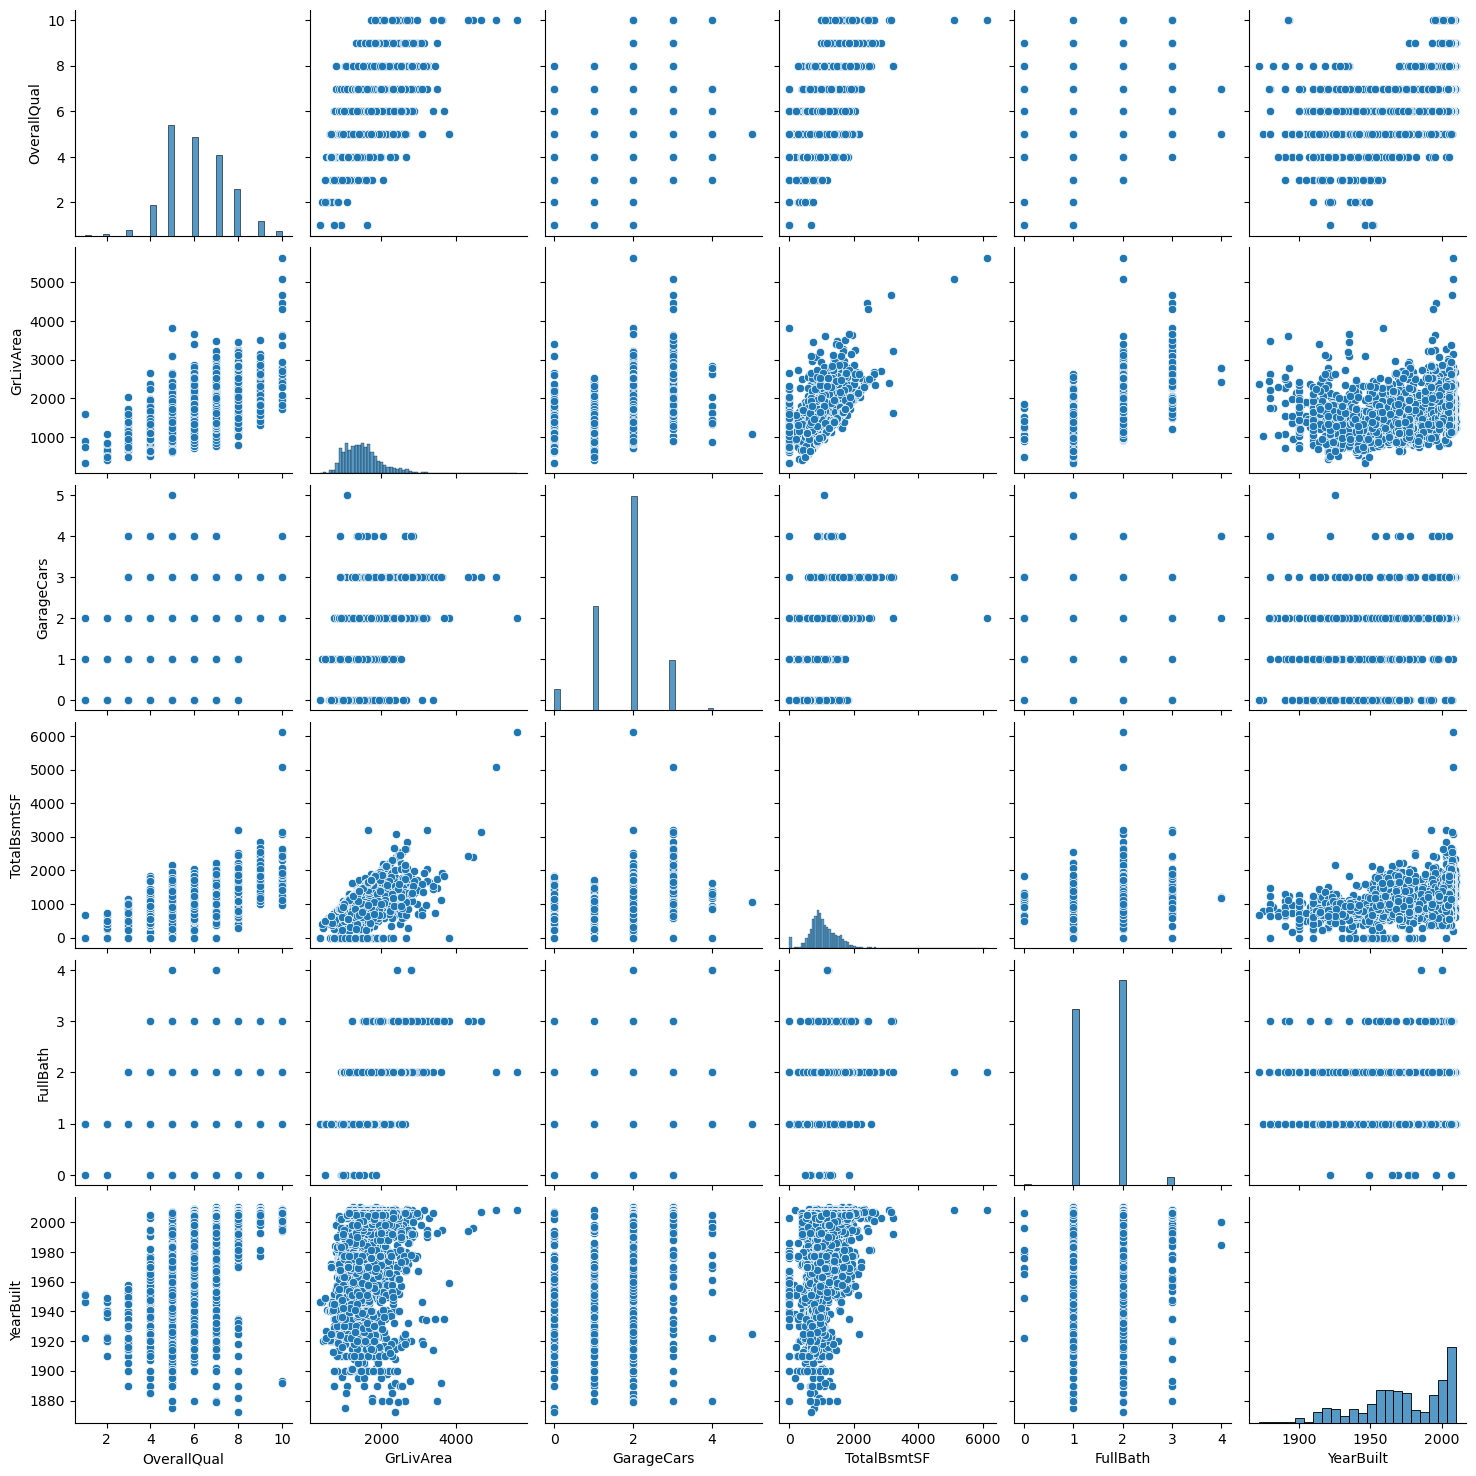

In [15]:
cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train[cols])

# Null Investigation

In [16]:
import missingno as msno

In [17]:
data = pd.concat([train, test], axis=0).drop(['Id','SalePrice'], axis=1)

In [18]:
nan_count = data.isnull().sum().sort_values(ascending=False)
nan_percent = (data.isna().sum()/len(data)).sort_values(ascending=False)
missing_data = pd.concat([nan_count, nan_percent], axis=1, keys=['nan_count', 'nan_percent'])
missing_data = missing_data[missing_data['nan_count']>0]
missing_data

,nan_count,nan_percent
PoolQC,4373,0.996355
MiscFeature,4232,0.964229
Alley,4084,0.930508
Fence,3527,0.803600
MasVnrType,2669,0.608111
FireplaceQu,2152,0.490317
LotFrontage,717,0.163363
GarageCond,237,0.053999
GarageFinish,237,0.053999
GarageYrBlt,237,0.053999


In [19]:
train_null = train.drop('Id',axis=1).isnull().sum()
test_null = test.drop('Id',axis=1).isnull().sum()
df_null = pd.concat([train_null,test_null], axis=1, keys=['train_null','test_null'])
df_null.sort_values(by='train_null',ascending=False).head(20)

,train_null,test_null
PoolQC,2917,1456.0
MiscFeature,2824,1408.0
Alley,2732,1352.0
Fence,2358,1169.0
MasVnrType,1775,894.0
FireplaceQu,1422,730.0
LotFrontage,490,227.0
GarageYrBlt,159,78.0
GarageQual,159,78.0
GarageCond,159,78.0


<Axes: >

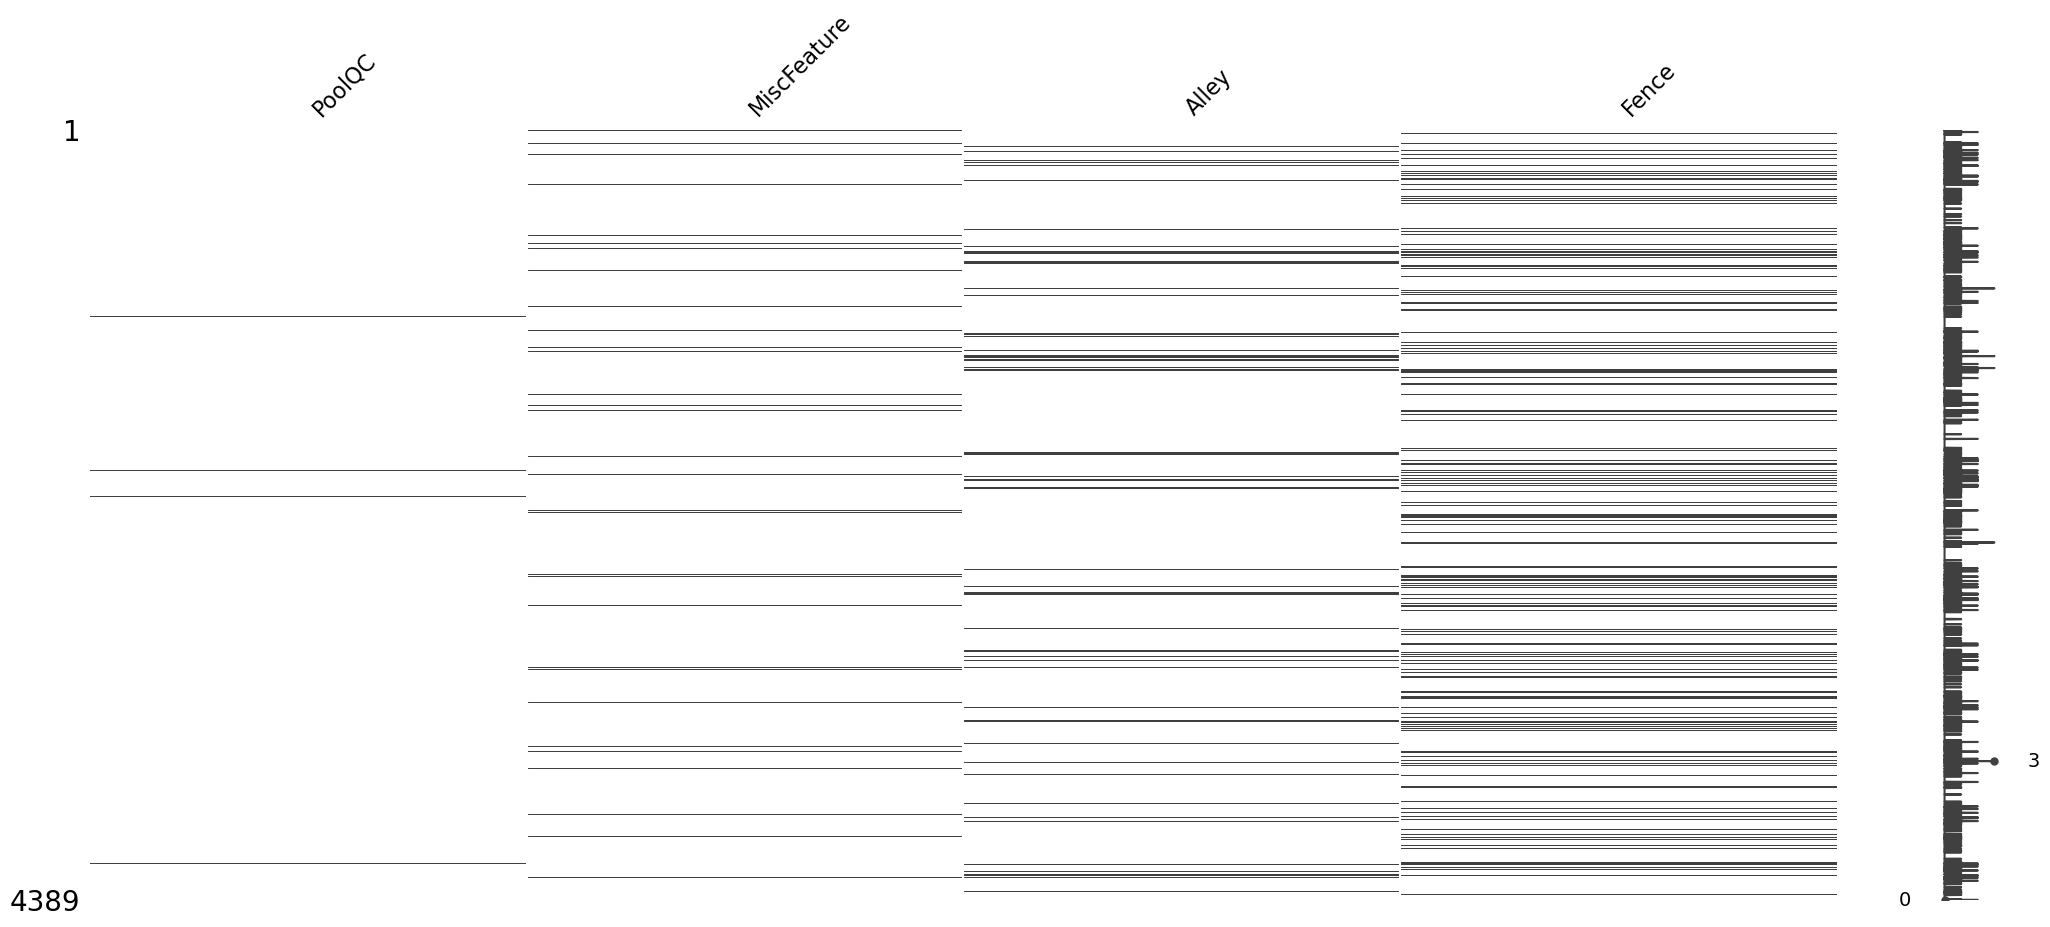

In [20]:
msno.matrix(data[['PoolQC','MiscFeature','Alley','Fence']])

In [21]:
na = ['Alley','Fence','FireplaceQu','PoolQC','MiscFeature']
train[na] = train[na].fillna('None')
test[na] = test[na].fillna('None')

In [22]:
fill_nan = missing_data[missing_data['nan_percent']<=0.06].index.to_list()
fill_nan

['GarageCond',
 'GarageFinish',
 'GarageYrBlt',
 'GarageQual',
 'GarageType',
 'BsmtExposure',
 'BsmtCond',
 'BsmtQual',
 'BsmtFinType2',
 'BsmtFinType1',
 'MasVnrArea',
 'BsmtHalfBath',
 'MSZoning',
 'BsmtFullBath',
 'BsmtFinSF1',
 'TotalBsmtSF',
 'BsmtFinSF2',
 'GarageCars',
 'BsmtUnfSF',
 'Utilities',
 'Functional',
 'GarageArea',
 'KitchenQual',
 'Exterior1st',
 'Electrical',
 'Exterior2nd',
 'SaleType']

In [23]:
data[fill_nan].dtypes

GarageCond          str
GarageFinish        str
GarageYrBlt     float64
GarageQual          str
GarageType          str
BsmtExposure        str
BsmtCond            str
BsmtQual            str
BsmtFinType2        str
BsmtFinType1        str
MasVnrArea      float64
BsmtHalfBath    float64
MSZoning            str
BsmtFullBath    float64
BsmtFinSF1      float64
TotalBsmtSF     float64
BsmtFinSF2      float64
GarageCars      float64
BsmtUnfSF       float64
Utilities           str
Functional          str
GarageArea      float64
KitchenQual         str
Exterior1st         str
Electrical          str
Exterior2nd         str
SaleType            str
dtype: object

In [24]:
num_fill = train[fill_nan].select_dtypes(['float64']).columns
cate_fill = train[fill_nan].select_dtypes(['str']).columns

<Axes: >

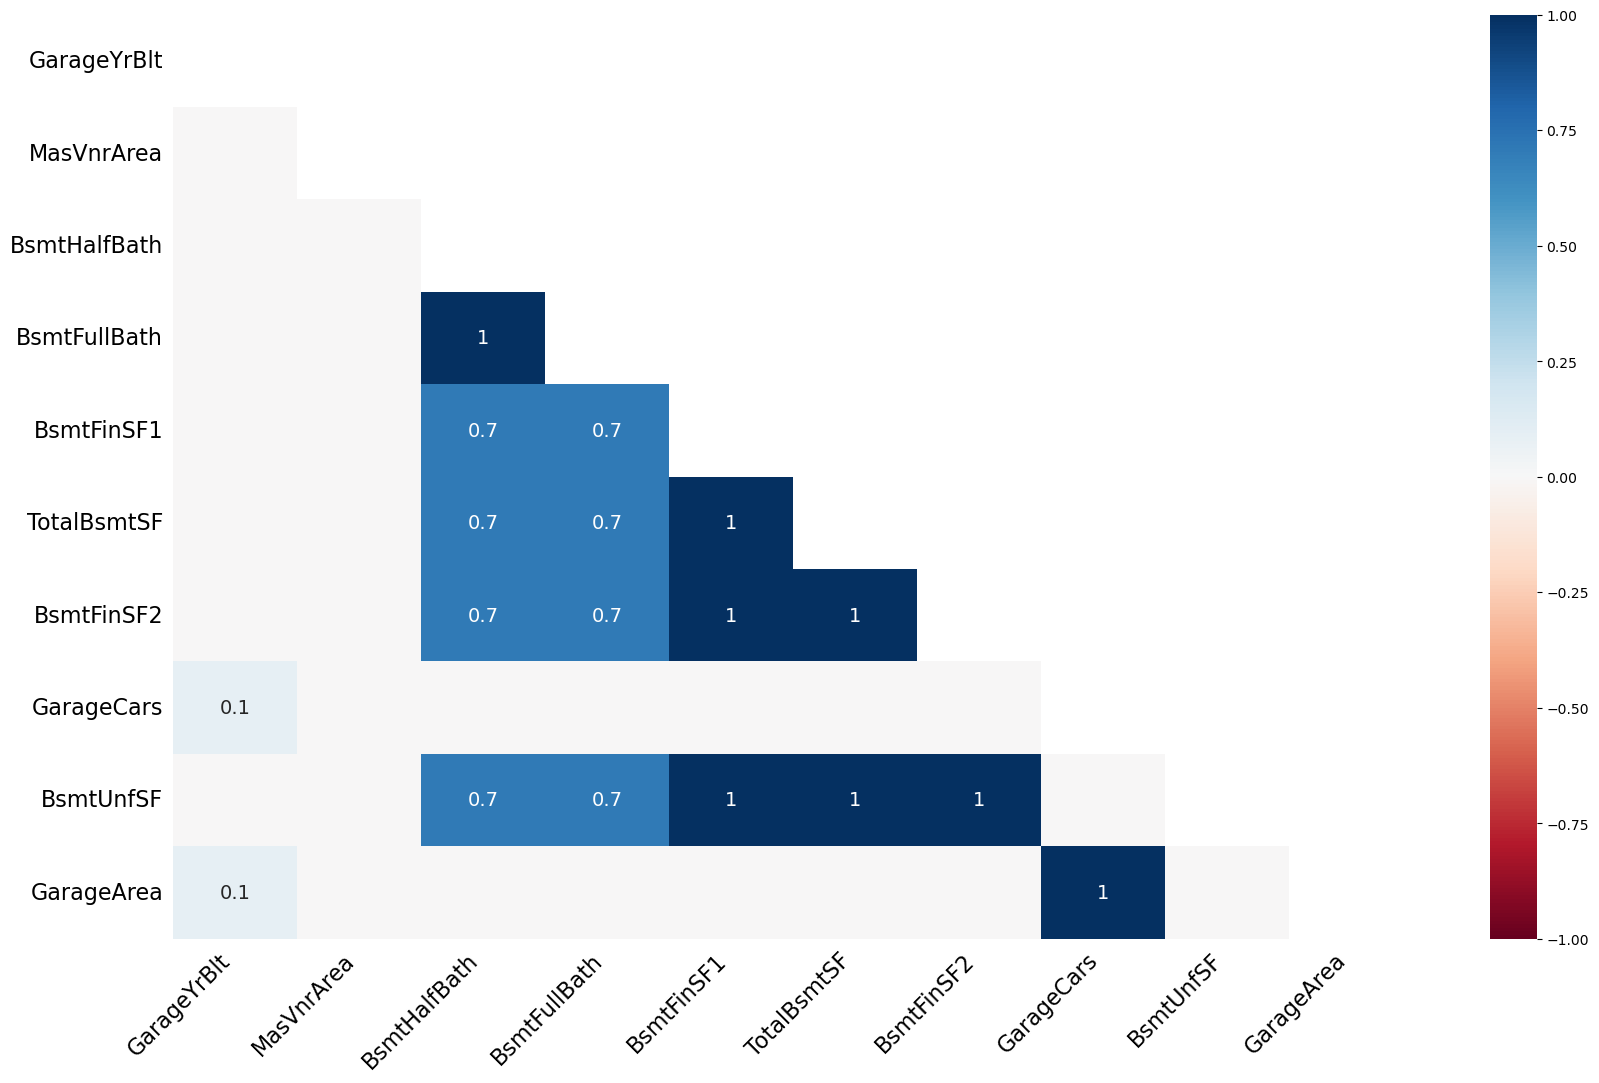

In [25]:
# correlation between missing values in different columns
msno.heatmap(data[num_fill])

<Axes: >

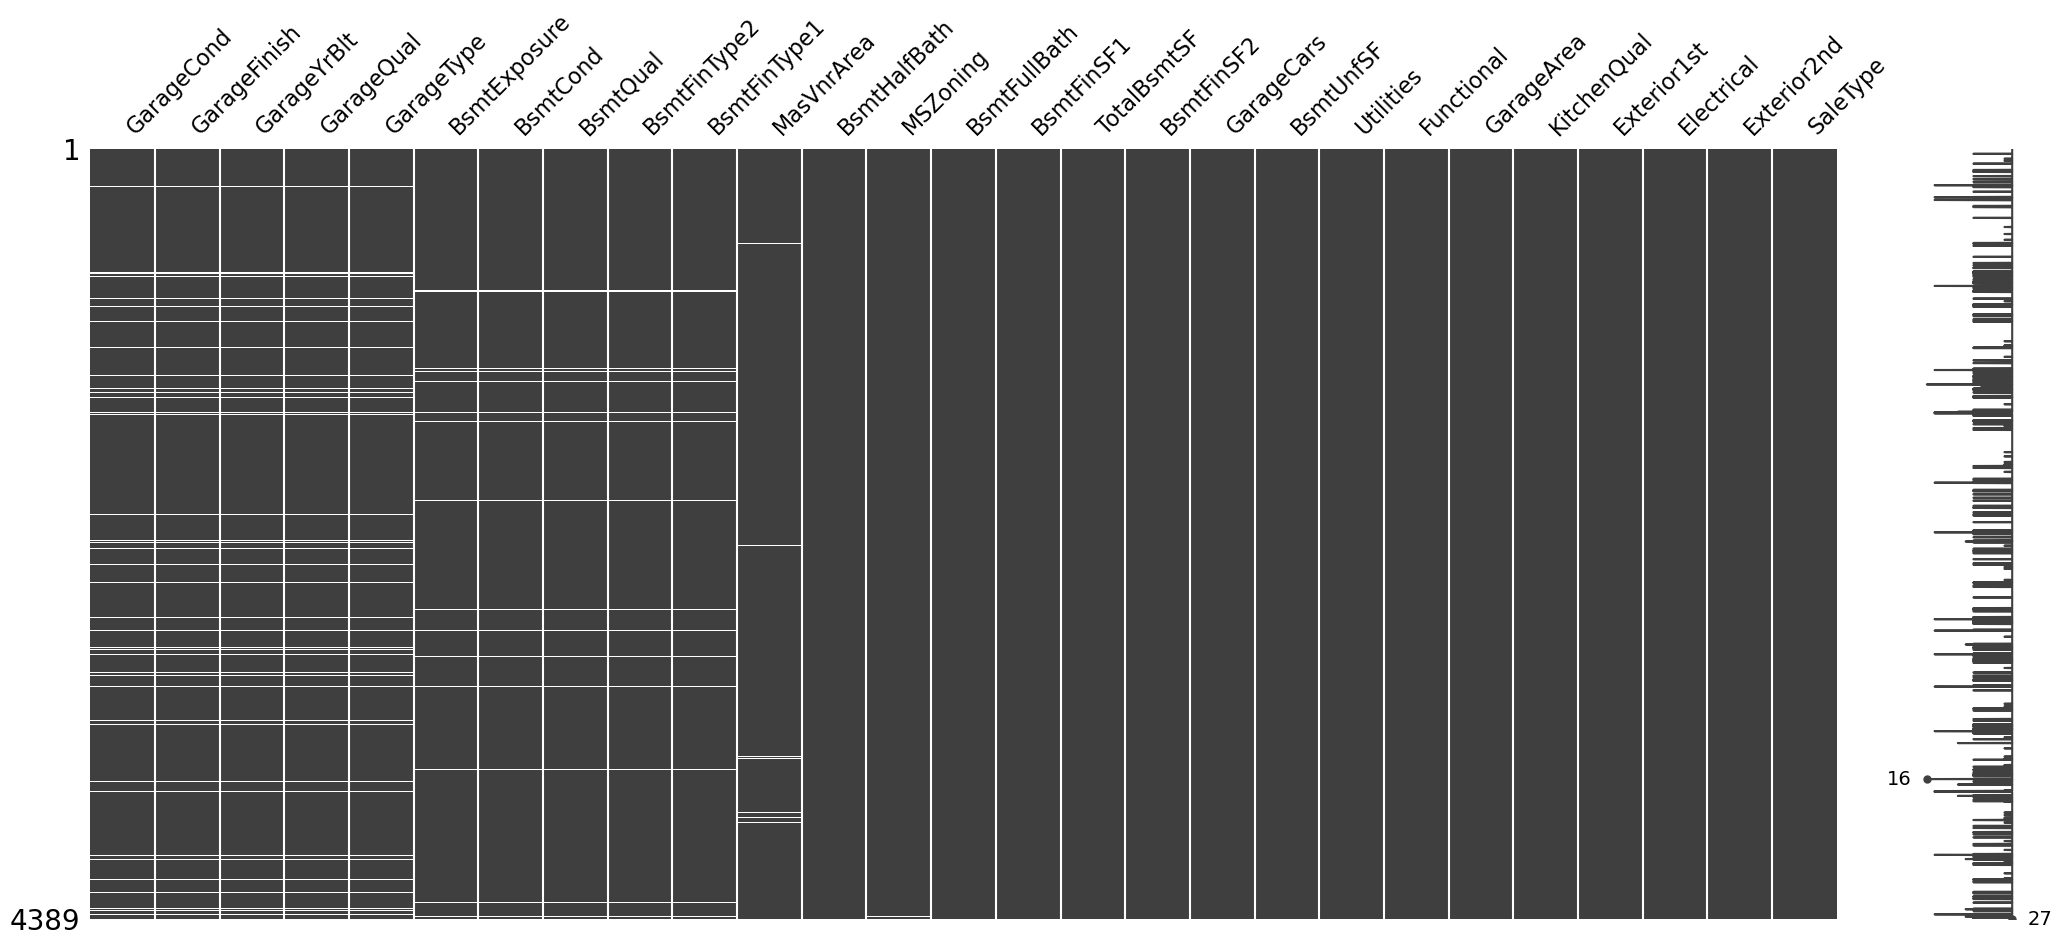

In [26]:
msno.matrix(data[fill_nan])

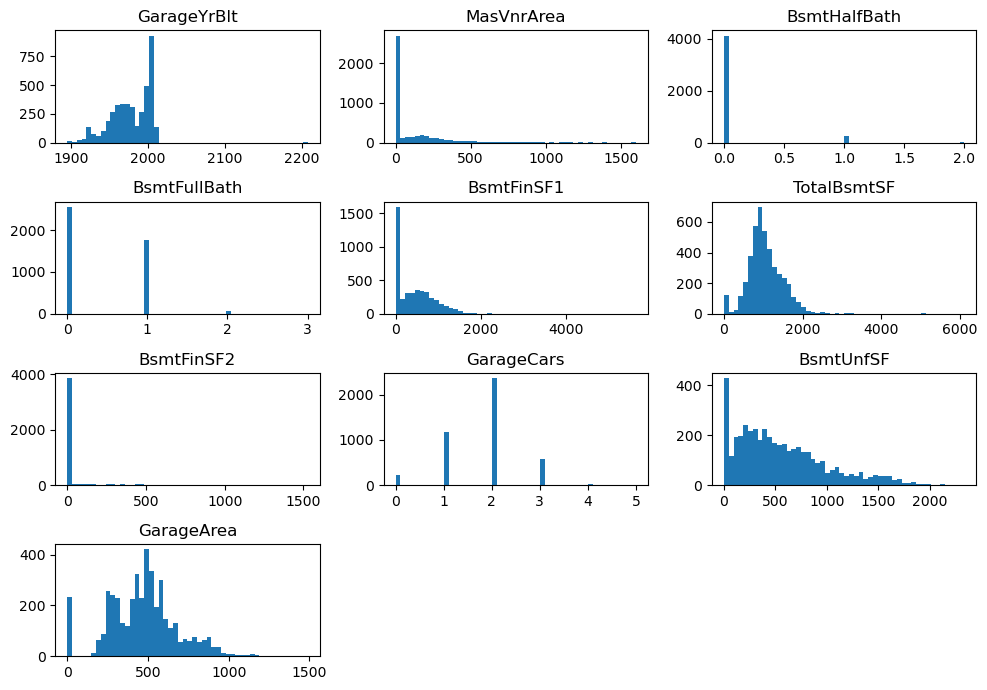

In [27]:
fig = plt.figure(figsize=(10, 7))

ncols = 3
nrows = int(np.ceil(data[num_fill].shape[1] / ncols))

for i, c in enumerate(data[num_fill].columns):
    ax = fig.add_subplot(nrows, ncols, i + 1)
    data[num_fill][c].plot.hist(bins=50, ax=ax)
    ax.set_title(c)
    ax.set_ylabel(None)

plt.tight_layout()
plt.show()

train[cate_fill] = train[cate_fill].fillna(train[cate_fill].mode().iloc[0])
test[cate_fill] = test[cate_fill].fillna(test[cate_fill].mode().iloc[0])

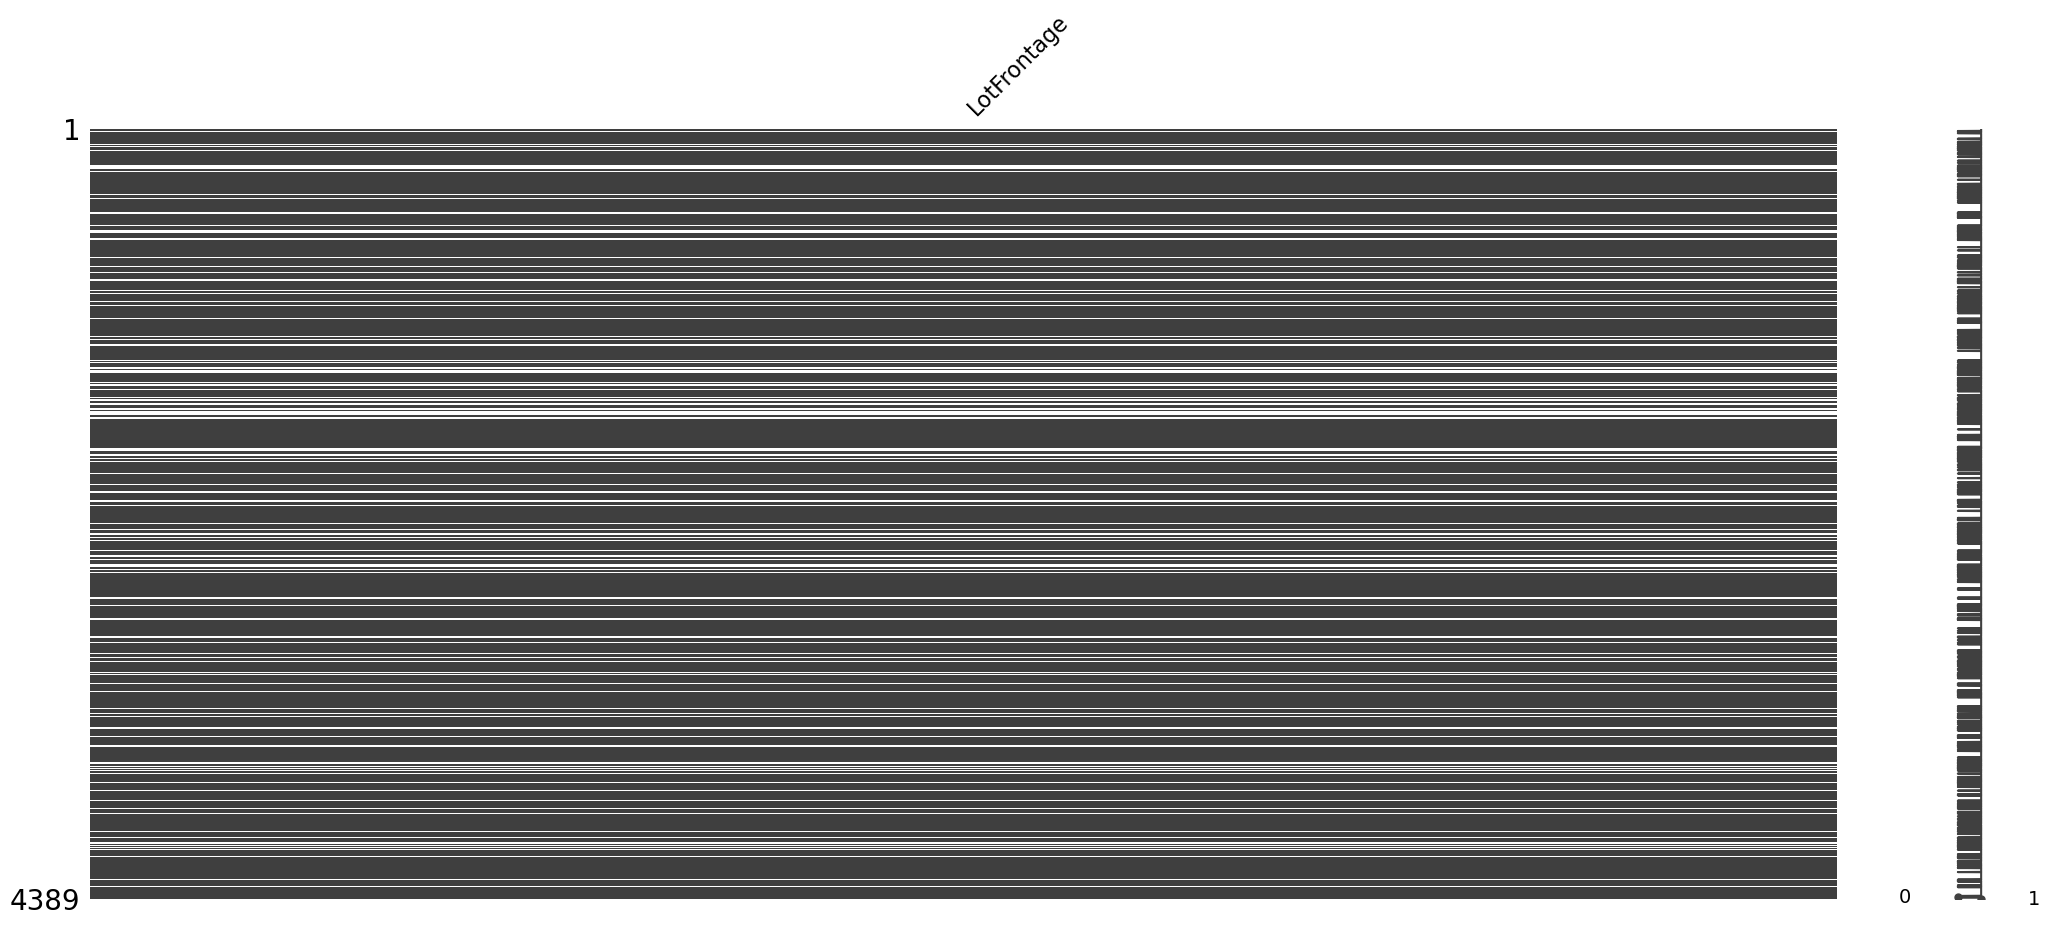

In [28]:
msno.matrix(data[['LotFrontage']])
plt.show()

In [29]:
lot_missing = data[data['LotFrontage'].isna()]
lot_complete = data[~data['LotFrontage'].isna()]

In [30]:
lot_missing.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,717.000000,0.0,717.000000,717.000000,717.000000,717.000000,717.000000,707.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,702.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000
mean,55.041841,NaN,12073.078103,6.114365,5.503487,1975.817294,1983.331939,113.964639,521.260809,65.330544,471.736402,1058.327755,1194.210600,363.675035,2.629010,1560.514644,0.496513,0.073919,1.622036,0.461646,2.935844,1.036262,6.490934,0.767085,1979.169516,1.889819,496.269177,118.301255,49.493724,20.414226,3.046025,16.114365,1.029289,67.615063,6.086471,2007.806137
std,36.799296,NaN,11124.249053,1.195091,1.142892,22.602005,18.219756,179.506240,406.969259,205.639080,403.855980,388.604997,352.730564,467.122523,34.254334,497.993142,0.532782,0.261822,0.582055,0.531409,0.854702,0.201451,1.497293,0.678998,19.802046,0.636742,175.038771,151.543773,62.488582,64.586415,26.168115,56.090517,27.561115,686.387415,2.602276,1.269569
min,20.000000,NaN,1533.000000,1.000000,1.000000,1900.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,530.000000,0.000000,0.000000,660.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,NaN,8145.000000,5.000000,5.000000,1963.000000,1967.000000,0.000000,149.000000,0.000000,186.000000,848.000000,924.000000,0.000000,0.000000,1160.000000,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,5.000000,0.000000,1966.000000,2.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,60.000000,NaN,10382.000000,6.000000,5.000000,1977.000000,1988.000000,0.000000,544.000000,0.000000,350.000000,1024.000000,1143.000000,0.000000,0.000000,1491.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,488.000000,81.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,NaN,12800.000000,7.000000,6.000000,1996.000000,2000.000000,180.000000,800.000000,0.000000,675.000000,1281.000000,1418.000000,783.000000,0.000000,1850.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,1997.000000,2.000000,578.000000,192.000000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2009.000000
max,190.000000,NaN,164660.000000,10.000000,9.000000,2009.000000,2010.000000,1159.000000,1733.000000,1526.000000,1969.000000,3200.000000,3228.000000,1721.000000,528.000000,3447.000000,2.000000,1.000000,4.000000,2.000000,6.000000,2.000000,13.000000,3.000000,2009.000000,4.000000,1356.000000,1424.000000,324.000000,584.000000,290.000000,490.000000,738.000000,15500.000000,12.000000,2010.000000


In [31]:
lot_complete.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3644.000000,3670.000000,3670.000000,3670.000000,3670.000000,3672.000000,3672.000000,3672.000000,3672.000000,3668.000000,3668.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3450.000000,3670.000000,3670.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000
mean,57.841776,69.008442,9641.386166,6.084695,5.571078,1970.485839,1984.209150,99.084797,425.906540,47.823978,574.388828,1048.119346,1151.590142,326.175926,4.626362,1482.392429,0.419847,0.060251,1.557462,0.362745,2.838235,1.045207,6.410675,0.559368,1977.756812,1.742507,468.218256,88.729031,47.460784,24.008170,2.186819,16.402233,2.282135,50.312636,6.196895,2007.779139
std,43.713553,23.037371,5850.065112,1.459399,1.105871,31.502471,21.441903,178.348752,462.760477,164.147894,443.313149,450.943605,401.173770,417.046251,47.459832,498.209231,0.524667,0.244762,0.547368,0.495368,0.822244,0.214241,1.562352,0.636033,26.887441,0.786169,222.498294,120.826653,68.963301,65.284232,23.086821,56.297356,35.099142,567.477919,2.739217,1.319745
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,20.000000,58.000000,7200.000000,5.000000,5.000000,1950.000000,1963.000000,0.000000,0.000000,0.000000,227.250000,780.000000,864.000000,0.000000,0.000000,1118.750000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1958.000000,1.000000,308.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,50.000000,68.000000,9254.000000,6.000000,5.000000,1972.000000,1993.000000,0.000000,330.000000,0.000000,483.000000,981.500000,1072.000000,0.000000,0.000000,1430.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.000000,1979.000000,2.000000,477.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,70.000000,80.000000,11195.000000,7.000000,6.000000,2003.000000,2004.000000,157.000000,724.000000,0.000000,817.000000,1308.000000,1380.000000,677.000000,0.000000,1717.250000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2003.000000,2.000000,576.000000,167.000000,69.250000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,870.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [32]:
num_fill = num_fill.to_list()
num_fill.append('LotFrontage')
for c in num_fill:
    train[c] = train[c].fillna(train[c].mean())
    test[c] = test[c].fillna(test[c].mean())

In [33]:
train[num_fill].info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GarageYrBlt   2930 non-null   float64
 1   MasVnrArea    2930 non-null   float64
 2   BsmtHalfBath  2930 non-null   float64
 3   BsmtFullBath  2930 non-null   float64
 4   BsmtFinSF1    2930 non-null   float64
 5   TotalBsmtSF   2930 non-null   float64
 6   BsmtFinSF2    2930 non-null   float64
 7   GarageCars    2930 non-null   float64
 8   BsmtUnfSF     2930 non-null   float64
 9   GarageArea    2930 non-null   float64
 10  LotFrontage   2930 non-null   float64
dtypes: float64(11)
memory usage: 251.9 KB


In [34]:
test[num_fill].info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GarageYrBlt   1459 non-null   float64
 1   MasVnrArea    1459 non-null   float64
 2   BsmtHalfBath  1459 non-null   float64
 3   BsmtFullBath  1459 non-null   float64
 4   BsmtFinSF1    1459 non-null   float64
 5   TotalBsmtSF   1459 non-null   float64
 6   BsmtFinSF2    1459 non-null   float64
 7   GarageCars    1459 non-null   float64
 8   BsmtUnfSF     1459 non-null   float64
 9   GarageArea    1459 non-null   float64
 10  LotFrontage   1459 non-null   float64
dtypes: float64(11)
memory usage: 125.5 KB


In [35]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2930 non-null   int64  
 1   MSSubClass     2930 non-null   int64  
 2   MSZoning       2930 non-null   str    
 3   LotFrontage    2930 non-null   float64
 4   LotArea        2930 non-null   int64  
 5   Street         2930 non-null   str    
 6   Alley          2930 non-null   str    
 7   LotShape       2930 non-null   str    
 8   LandContour    2930 non-null   str    
 9   Utilities      2930 non-null   str    
 10  LotConfig      2930 non-null   str    
 11  LandSlope      2930 non-null   str    
 12  Neighborhood   2930 non-null   str    
 13  Condition1     2930 non-null   str    
 14  Condition2     2930 non-null   str    
 15  BldgType       2930 non-null   str    
 16  HouseStyle     2930 non-null   str    
 17  OverallQual    2930 non-null   int64  
 18  OverallCond    2930

In [36]:
# print(train.isnull().sum().max(), test.isnull().sum().max())

# Cleaning data

In [37]:
train = train.rename(columns={'YearRemod/Add':'YearRemodAdd'})
data = pd.concat([train, test], axis=0).drop('SalePrice', axis=1).reset_index(drop=True)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.000000,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,None,None,None,0,5,2010,WD,Normal
1,2,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,None,Attchd,1961.000000,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,None,MnPrv,None,0,6,2010,WD,Normal
2,3,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,None,Attchd,1958.000000,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,None,None,Gar2,12500,6,2010,WD,Normal
3,4,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.000000,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,None,None,None,0,4,2010,WD,Normal
4,5,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.000000,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,None,MnPrv,None,0,3,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4384,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,Attchd,1977.721217,Unf,0.0,0.0,TA,TA,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal
4385,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.000000,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml
4386,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.000000,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml
4387,2918,85,RL,62.0,10441,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel

In [38]:
data.isnull().sum().max()

2669

## Data Type constraints

In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4389 entries, 0 to 4388
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             4389 non-null   int64  
 1   MSSubClass     4389 non-null   int64  
 2   MSZoning       4389 non-null   str    
 3   LotFrontage    4389 non-null   float64
 4   LotArea        4389 non-null   int64  
 5   Street         4389 non-null   str    
 6   Alley          4389 non-null   str    
 7   LotShape       4389 non-null   str    
 8   LandContour    4389 non-null   str    
 9   Utilities      4389 non-null   str    
 10  LotConfig      4389 non-null   str    
 11  LandSlope      4389 non-null   str    
 12  Neighborhood   4389 non-null   str    
 13  Condition1     4389 non-null   str    
 14  Condition2     4389 non-null   str    
 15  BldgType       4389 non-null   str    
 16  HouseStyle     4389 non-null   str    
 17  OverallQual    4389 non-null   int64  
 18  OverallCond    4389

In [40]:
data.select_dtypes('str').head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,Plywood,Stone,TA,TA,CBlock,TA,Gd,Gd,BLQ,Unf,GasA,Fa,Y,SBrkr,TA,Typ,Gd,Attchd,Fin,TA,TA,P,None,None,None,WD,Normal
1,RH,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,CBlock,TA,TA,No,Rec,LwQ,GasA,TA,Y,SBrkr,TA,Typ,None,Attchd,Unf,TA,TA,Y,None,MnPrv,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,TA,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,TA,Y,SBrkr,Gd,Typ,None,Attchd,Unf,TA,TA,Y,None,None,Gar2,WD,Normal
3,RL,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,BrkFace,NaN,Gd,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,Ex,Y,SBrkr,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,None,None,None,WD,Normal
4,RL,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Gd,Y,SBrkr,TA,Typ,TA,Attchd,Fin,TA,TA,Y,None,MnPrv,None,WD,Normal


In [41]:
data['Neighborhood'].value_counts()

Neighborhood
NAmes      661
CollgCr    384
OldTown    365
Edwards    288
Somerst    278
NridgHt    255
Gilbert    251
Sawyer     228
SawyerW    191
NWAmes     189
Mitchel    179
BrkSide    158
Crawfor    155
IDOTRR     149
Timber     106
NoRidge    101
StoneBr     77
SWISU       71
ClearCr     60
MeadowV     57
BrDale      44
Blmngtn     39
NPkVill     37
Veenker     37
Blueste     18
Greens       8
GrnHill      2
Landmrk      1
Name: count, dtype: int64

In [42]:
cate = data.select_dtypes('str').columns.to_list()
data[cate] = data[cate].astype('category')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4389 entries, 0 to 4388
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             4389 non-null   int64   
 1   MSSubClass     4389 non-null   int64   
 2   MSZoning       4389 non-null   category
 3   LotFrontage    4389 non-null   float64 
 4   LotArea        4389 non-null   int64   
 5   Street         4389 non-null   category
 6   Alley          4389 non-null   category
 7   LotShape       4389 non-null   category
 8   LandContour    4389 non-null   category
 9   Utilities      4389 non-null   category
 10  LotConfig      4389 non-null   category
 11  LandSlope      4389 non-null   category
 12  Neighborhood   4389 non-null   category
 13  Condition1     4389 non-null   category
 14  Condition2     4389 non-null   category
 15  BldgType       4389 non-null   category
 16  HouseStyle     4389 non-null   category
 17  OverallQual    4389 non-null   int64   
 18 

In [43]:
data.select_dtypes(['int64','float64']).head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,0,0,1656,1.0,0.0,1,0,3,1,7,2,1960.0,2.0,528.0,210,62,0,0,0,0,0,5,2010
1,2,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010
2,3,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,0,0,1329,0.0,0.0,1,1,3,1,6,0,1958.0,1.0,312.0,393,36,0,0,0,0,12500,6,2010
3,4,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,0,0,2110,1.0,0.0,2,1,3,1,8,2,1968.0,2.0,522.0,0,0,0,0,0,0,0,4,2010
4,5,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,928.0,928,701,0,1629,0.0,0.0,2,1,3,1,6,1,1997.0,2.0,482.0,212,34,0,0,0,0,0,3,2010


In [44]:
check_col = ['MSSubClass','OverallQual','OverallCond','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','BedroomAbvGr','KitchenAbvGr','MoSold']
for c in check_col:
    print(data[c].value_counts().sort_index())

MSSubClass
20     1622
30      209
40        8
45       24
50      430
60      851
70      196
75       30
80      178
85       76
90      166
120     287
150       2
160     194
180      24
190      92
Name: count, dtype: int64
OverallQual
1        6
2       23
3       60
4      336
5     1253
6     1089
7      883
8      524
9      171
10      44
Name: count, dtype: int64
OverallCond
1      13
2      15
3      75
4     145
5    2478
6     812
7     575
8     216
9      60
Name: count, dtype: int64
BsmtFullBath
0.000000    2556
0.431352       2
0.434454       2
1.000000    1765
2.000000      61
3.000000       3
Name: count, dtype: int64
BsmtHalfBath
0.000000    4117
0.061134       2
0.065202       2
1.000000     262
2.000000       6
Name: count, dtype: int64
FullBath
0      15
1    1977
2    2294
3      95
4       8
Name: count, dtype: int64
HalfBath
0    2764
1    1587
2      38
Name: count, dtype: int64
BedroomAbvGr
0      10
1     165
2    1127
3    2389
4     587
5      75
6      

In [45]:
data['MSSubClass'] = data['MSSubClass'].apply(str).astype('category')
data['YrSold'] = data['YrSold'].apply(str).astype('category')
data['MoSold'] = data['MoSold'].apply(str).astype('category')

## Check duplicate

In [46]:
duplicates = data.duplicated()
data[duplicates]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


## Lowercase & strip

In [47]:
for c in cate:
    data[c] = data[c].str.lower().str.strip().astype('category')
data['SaleType'].value_counts()

SaleType
wd       3795
new       356
cod       131
conld      43
cwd        20
conli      13
conlw      11
oth        11
con         8
vwd         1
Name: count, dtype: int64

## Data Range constraints

In [48]:
data.select_dtypes(['int64','float64']).describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
count,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.00000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000
mean,1706.339713,69.010433,10038.634541,6.089542,5.560036,1971.356801,1984.065846,101.501997,441.490734,50.685428,557.61120,1049.787362,1158.552746,332.301891,4.300068,1495.154705,0.432384,0.062486,1.568011,0.378902,2.854181,1.043746,6.423787,0.593301,1977.995742,1.766583,472.802823,93.560036,47.792891,23.421053,2.327182,16.355206,2.077466,53.139212
std,808.203314,21.071671,7044.993407,1.419506,1.112151,30.290079,20.950010,177.826021,455.330740,171.672772,438.60947,441.231826,393.945098,425.798977,45.567449,498.953983,0.526465,0.247540,0.553630,0.502702,0.828321,0.212208,1.552027,0.647737,25.122538,0.765449,215.640082,126.808816,67.945124,65.176973,23.616631,56.257339,33.982520,588.495661
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.00000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1098.000000,60.000000,7424.000000,5.000000,5.000000,1953.000000,1965.000000,0.000000,0.000000,0.000000,219.00000,789.000000,875.000000,0.000000,0.000000,1124.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,319.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1828.000000,69.224590,9430.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,364.000000,0.000000,462.00000,988.000000,1082.000000,0.000000,0.000000,1440.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.132443,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2376.000000,78.000000,11553.000000,7.000000,6.000000,2001.000000,2004.000000,162.000000,739.000000,0.000000,801.00000,1302.000000,1384.000000,695.000000,0.000000,1734.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2930.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.00000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000


### Univariate outliers analysis

In [49]:
num_col = train.select_dtypes(['int64','float64'])
num_col.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,0,0,1656,1.0,0.0,1,0,3,1,7,2,1960.0,2.0,528.0,210,62,0,0,0,0,0,5,2010,12.278398
1,2,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010,11.561725
2,3,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,0,0,1329,0.0,0.0,1,1,3,1,6,0,1958.0,1.0,312.0,393,36,0,0,0,0,12500,6,2010,12.055256
3,4,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,0,0,2110,1.0,0.0,2,1,3,1,8,2,1968.0,2.0,522.0,0,0,0,0,0,0,0,4,2010,12.404928
4,5,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,928.0,928,701,0,1629,0.0,0.0,2,1,3,1,6,1,1997.0,2.0,482.0,212,34,0,0,0,0,0,3,2010,12.154258


In [50]:
def doutlier_dect(d, whisker_width=1.5):
    q25 = d.quantile(0.25)
    q75 = d.quantile(0.75)
    iqr = q75 - q25
    return d[(d > q75+whisker_width*iqr) | (d < q25-whisker_width*iqr)]

In [51]:
doutlier_dect(num_col, whisker_width=1.5).count().sort_values(ascending=False)

EnclosedPorch    459
BsmtFinSF2       352
LotFrontage      261
ScreenPorch      256
OverallCond      252
MSSubClass       208
MasVnrArea       203
BsmtHalfBath     177
OpenPorchSF      159
KitchenAbvGr     134
LotArea          127
TotalBsmtSF      123
MiscVal          103
BedroomAbvGr      78
GrLivArea         75
WoodDeckSF        67
SalePrice         60
BsmtUnfSF         56
TotRmsAbvGrd      51
1stFlrSF          43
GarageArea        42
LowQualFinSF      40
3SsnPorch         37
GarageCars        17
BsmtFinSF1        15
Fireplaces        13
PoolArea          13
YearBuilt          9
GarageYrBlt        9
2ndFlrSF           8
FullBath           4
OverallQual        4
BsmtFullBath       2
Id                 0
HalfBath           0
YearRemodAdd       0
MoSold             0
YrSold             0
dtype: int64

In [52]:
outlier = doutlier_dect(num_col, whisker_width=1.5).dropna(how='all')
outlier

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,NaN,NaN,141.0,31770.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12500.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2924,NaN,NaN,160.0,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,324.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,700.0,NaN,NaN,NaN


In [53]:
out_price = outlier[outlier['SalePrice'].notnull()]
out_price.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
15,NaN,NaN,NaN,53504.0,NaN,NaN,NaN,NaN,603.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3279.0,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN,NaN,503.0,NaN,NaN,NaN,210.0,NaN,NaN,NaN,NaN,13.195616
44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,760.0,2188.0,NaN,NaN,2330.0,2364.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.323929
46,NaN,NaN,110.0,NaN,NaN,NaN,NaN,NaN,1095.0,NaN,NaN,NaN,2846.0,2696.0,NaN,NaN,2696.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.122365
181,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.456419
206,NaN,190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3500.0,NaN,NaN,10.915107


In [54]:
out_price.count().sort_values(ascending=False)

SalePrice        60
MasVnrArea       25
TotalBsmtSF      22
GrLivArea        16
1stFlrSF         15
OverallCond      13
LotFrontage      12
EnclosedPorch    12
ScreenPorch      12
TotRmsAbvGrd      9
BsmtFinSF1        8
OpenPorchSF       8
LotArea           8
GarageArea        7
2ndFlrSF          4
BsmtUnfSF         3
OverallQual       3
WoodDeckSF        2
MiscVal           2
PoolArea          2
LowQualFinSF      2
BsmtFinSF2        2
GarageCars        1
MSSubClass        1
Fireplaces        1
KitchenAbvGr      1
BsmtHalfBath      1
BedroomAbvGr      1
GarageYrBlt       1
Id                0
HalfBath          0
FullBath          0
BsmtFullBath      0
YearRemodAdd      0
YearBuilt         0
3SsnPorch         0
MoSold            0
YrSold            0
dtype: int64

### Multivariate outlier analysis

In [55]:
doutlier_dect(num_col, whisker_width=1.5)[highest_corr_features].count().sort_values(ascending=False)

TotalBsmtSF     123
GrLivArea        75
SalePrice        60
1stFlrSF         43
GarageArea       42
GarageCars       17
YearBuilt         9
GarageYrBlt       9
OverallQual       4
FullBath          4
YearRemodAdd      0
dtype: int64

In [56]:
out_price[highest_corr_features].count().sort_values(ascending=False)

SalePrice       60
TotalBsmtSF     22
GrLivArea       16
1stFlrSF        15
GarageArea       7
OverallQual      3
GarageCars       1
GarageYrBlt      1
YearBuilt        0
YearRemodAdd     0
FullBath         0
dtype: int64

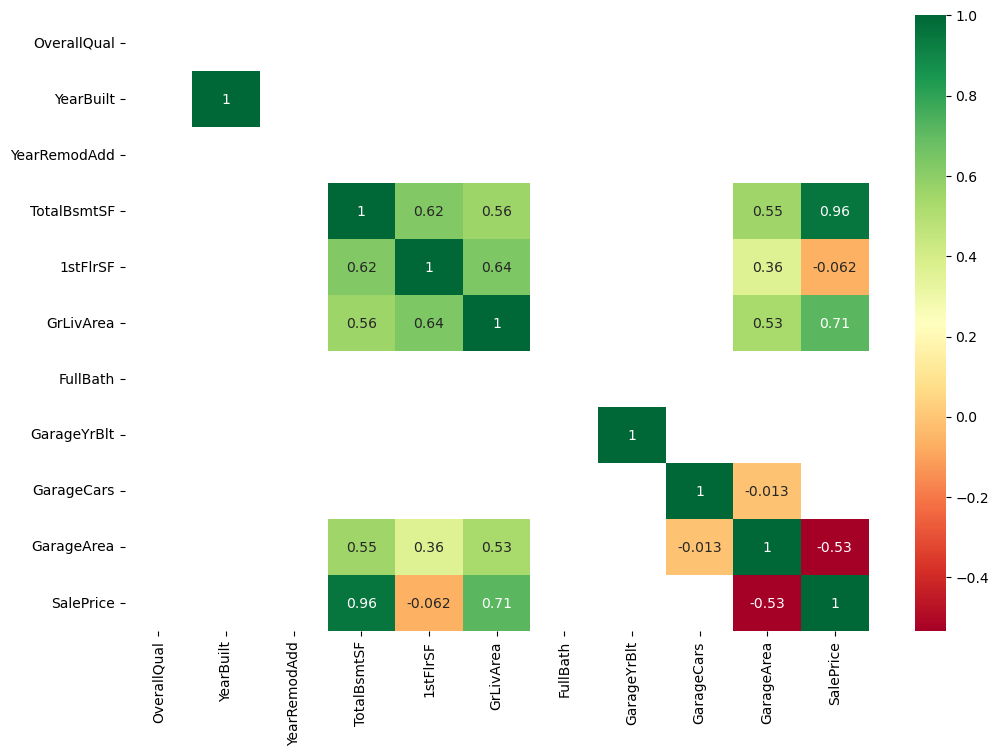

In [57]:
plt.figure(figsize=(12,8))
g = sns.heatmap(outlier[highest_corr_features].corr(),annot=True,cmap="RdYlGn")

In [58]:
# many outliers in dataset, but outliers of key feature having high corr with outliers of target variable
# => log scale to make sure not missing data

# Feature Engineering

## Create new feature

In [59]:
data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']

data['Total_Bathrooms'] = (data['FullBath'] + (0.5 * data['HalfBath'])\
                           + data['BsmtFullBath'] + (0.5 * data['BsmtHalfBath']))

data['Total_porch_sf'] = (data['OpenPorchSF'] + data['3SsnPorch']\
                          + data['EnclosedPorch'] + data['ScreenPorch'] + data['WoodDeckSF'])

In [60]:
data["SqFtPerRoom"] = data["GrLivArea"] / (data["TotRmsAbvGrd"] +
                                                       data["FullBath"] +
                                                       data["HalfBath"] +
                                                       data["KitchenAbvGr"])

data['Total_Home_Quality'] = data['OverallQual'] + data['OverallCond']

data["HighQualSF"] = data["1stFlrSF"] + data["2ndFlrSF"]

In [61]:
data['pool'] = data['PoolArea'].apply(lambda x: 1 if x > 0 else 0).astype('category')
data['2ndfloor'] = data['2ndFlrSF'].apply(lambda x: 1 if x > 0 else 0).astype('category')
data['garage'] = data['GarageArea'].apply(lambda x: 1 if x > 0 else 0).astype('category')
data['bsmt'] = data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0).astype('category')
data['fireplace'] = data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0).astype('category')

## Fix skew data

In [62]:
num_col = data.select_dtypes(['int64','float64']).columns
skew_col = data[num_col].apply(lambda x: skew(x)).sort_values(ascending=False)
high_skew = skew_col[abs(skew_col)>0.5]
high_skew

MiscVal               21.287469
PoolArea              17.833681
LowQualFinSF          13.332476
LotArea               12.352460
3SsnPorch             11.791170
EnclosedPorch          4.253796
KitchenAbvGr           4.238255
BsmtFinSF2             4.105617
ScreenPorch            3.897400
BsmtHalfBath           3.884655
MasVnrArea             2.592563
OpenPorchSF            2.586887
WoodDeckSF             1.939138
1stFlrSF               1.498762
Total_porch_sf         1.460106
TotalSF                1.421193
LotFrontage            1.358726
BsmtFinSF1             1.332481
GrLivArea              1.231112
HighQualSF             1.222183
TotalBsmtSF            1.040632
BsmtUnfSF              0.921654
2ndFlrSF               0.881220
SqFtPerRoom            0.858781
TotRmsAbvGrd           0.782310
Fireplaces             0.765274
HalfBath               0.702887
BsmtFullBath           0.627815
Total_Bathrooms        0.562609
OverallCond            0.532256
YearBuilt             -0.598420
Total_Ho

In [63]:
for f in high_skew.index:
    data[f] = np.log1p(data[f])

## Encoding category variables

In [64]:
def test_mean_target_encoding(train, test, target, categorical, alpha=5):
    # Calculate global mean on the train data
    global_mean = train[target].mean()
    
    # Group by the categorical feature and calculate its properties
    train_groups = train.groupby(categorical)
    category_sum = train_groups[target].sum()
    category_size = train_groups.size()
    
    # Calculate smoothed mean target statistics
    train_statistics = (category_sum + global_mean * alpha) / (category_size + alpha)
    
    # Apply statistics to the test data and fill new categories
    test_feature = test[categorical].map(train_statistics).fillna(global_mean)
    return test_feature.values

In [65]:
from sklearn.model_selection import KFold
def train_mean_target_encoding(train, target, categorical, alpha=5):
    # Create 5-fold cross-validation
    kf = KFold(n_splits=5, random_state=123, shuffle=True)
    train_feature = pd.Series(index=train.index)
    
    # For each folds split
    for train_index, test_index in kf.split(train):
        cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]
      
        # Calculate out-of-fold statistics and apply to cv_test
        cv_test_feature = test_mean_target_encoding(cv_train, cv_test, target, categorical, alpha)
        
        # Save new feature for this particular fold
        train_feature.iloc[test_index] = cv_test_feature       
    return train_feature.values

In [66]:
def mean_target_encoding(train, test, target, categorical, alpha=5):
  
    # Get the train feature
    train_feature = train_mean_target_encoding(train, target, categorical, alpha)
  
    # Get the test feature
    test_feature = test_mean_target_encoding(train, test, target, categorical, alpha)
    
    # Return new features to add to the model
    return train_feature, test_feature

In [67]:
cate = data.select_dtypes('category').columns
data[cate].head()

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition,pool,2ndfloor,garage,bsmt,fireplace
0,20,rl,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,hip,compshg,brkface,plywood,stone,ta,ta,cblock,ta,gd,gd,blq,unf,gasa,fa,y,sbrkr,ta,typ,gd,attchd,fin,ta,ta,p,none,none,none,5,2010,wd,normal,0,0,1,1,1
1,20,rh,pave,none,reg,lvl,allpub,inside,gtl,names,feedr,norm,1fam,1story,gable,compshg,vinylsd,vinylsd,NaN,ta,ta,cblock,ta,ta,no,rec,lwq,gasa,ta,y,sbrkr,ta,typ,none,attchd,unf,ta,ta,y,none,mnprv,none,6,2010,wd,normal,0,0,1,1,0
2,20,rl,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,hip,compshg,wd sdng,wd sdng,brkface,ta,ta,cblock,ta,ta,no,alq,unf,gasa,ta,y,sbrkr,gd,typ,none,attchd,unf,ta,ta,y,none,none,gar2,6,2010,wd,normal,0,0,1,1,0
3,20,rl,pave,none,reg,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,hip,compshg,brkface,brkface,NaN,gd,ta,cblock,ta,ta,no,alq,unf,gasa,ex,y,sbrkr,ex,typ,ta,attchd,fin,ta,ta,y,none,none,none,4,2010,wd,normal,0,0,1,1,1
4,60,rl,pave,none,ir1,lvl,allpub,inside,gtl,gilbert,norm,norm,1fam,2story,gable,compshg,vinylsd,vinylsd,NaN,ta,ta,pconc,gd,ta,no,glq,unf,gasa,gd,y,sbrkr,ta,typ,ta,attchd,fin,ta,ta,y,none,mnprv,none,3,2010,wd,normal,0,1,1,1,1


In [68]:
X_train = data[:max(train['Id'])]
y_train = train['SalePrice']
df_train = pd.concat([X_train,y_train],axis=1)
df_test = data[max(train['Id']):]

In [69]:
df_train.shape, df_test.shape

((2930, 92), (1459, 91))

In [70]:
for c in data[cate].columns:
    df_train[c] = df_train[c].astype('object')
    df_test[c] = df_test[c].astype('object')
    train_feature, test_feature = mean_target_encoding(df_train, df_test, 'SalePrice', c, alpha=5)
    df_train[c] = train_feature
    df_test[c] = test_feature
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,Total_Bathrooms,Total_porch_sf,SqFtPerRoom,Total_Home_Quality,HighQualSF,pool,2ndfloor,garage,bsmt,fireplace,SalePrice
0,1,12.053279,12.086144,4.955827,10.366309,12.020160,12.032251,12.187782,12.011431,12.018321,12.026459,12.012976,11.860776,12.036892,12.018396,12.035646,11.996695,6,1.791759,7.581210,1960,12.218759,12.013677,12.013857,11.965834,12.361805,4.727388,11.830194,12.040513,11.869209,11.795345,12.234945,12.395295,11.872323,6.461468,12.020882,0.000000,6.091310,6.985642,12.023288,11.694570,12.056366,12.053253,7.412764,0.000000,0.0,7.412764,0.693147,0.0,1,0.000000,3,0.693147,11.807320,2.079442,12.032986,1.098612,12.265607,12.103704,1960.0,12.318383,2.0,528.0,12.035492,12.034801,11.782760,5.351858,4.143135,0.0,0.0,0.000000,0.0,12.016393,12.051992,12.022646,0.000000,11.971583,11.971811,11.992568,12.001001,7.914618,1.098612,5.609472,5.220356,2.484907,7.412764,12.016393,11.979872,12.043235,12.031897,12.217855,12.278398
1,2,12.056869,11.905423,4.394449,9.360741,12.029154,12.039983,11.929646,12.018645,12.027649,12.009018,12.022800,11.869201,11.836529,12.026063,12.047977,12.005557,5,1.945910,7.581720,1961,11.984664,12.025075,12.216563,12.212489,12.027112,0.000000,11.836221,12.047822,11.870151,11.795421,12.028835,11.937776,11.838519,6.150603,12.003807,4.976734,5.602119,6.783325,12.033737,11.801291,12.065826,12.065025,6.799056,0.000000,0.0,6.799056,0.000000,0.0,1,0.000000,2,0.693147,11.815815,1.791759,12.042453,0.000000,11.813518,12.107842,1961.0,11.784138,1.0,730.0,12.044766,12.041124,12.071710,4.948760,0.000000,0.0,0.0,4.795791,0.0,12.025534,11.863377,12.031464,0.000000,12.029976,11.971222,11.998699,12.010184,7.483807,0.693147,5.564520,4.859812,2.484907,6.799056,12.025534,11.988920,12.055482,12.040817,11.813518,11.561725
2,3,12.056031,12.085561,4.406719,9.565775,12.021623,12.032823,12.187479,12.012794,12.019866,12.003913,12.014718,11.863464,12.039494,12.019763,12.037896,12.005414,6,1.945910,7.580189,1958,12.213997,12.016073,11.829125,11.833627,12.192993,4.691348,11.830450,12.042288,11.856878,11.791826,12.027870,11.925788,11.966917,6.828712,12.022097,0.000000,6.008813,7.192934,12.025090,11.795140,12.059342,12.053310,7.192934,0.000000,0.0,7.192934,0.000000,0.0,1,0.693147,3,0.693147,12.211527,1.945910,12.032962,0.000000,11.806396,12.107207,1958.0,11.776582,1.0,312.0,12.035914,12.035741,12.064792,5.976351,3.610918,0.0,0.0,0.000000,0.0,12.017702,12.054428,11.935582,9.433564,12.027130,11.975457,11.993451,12.004523,7.885705,0.916291,6.063785,5.001707,2.564949,7.192934,12.017702,11.986344,12.049438,12.031822,11.806396,12.055256
3,4,12.056869,12.087640,4.543295,9.320181,12.029154,12.039983,11.929646,12.018645,12.027649,12.015130,12.022800,11.869201,12.042563,12.026063,12.047977,12.005557,7,1.791759,7.585281,1968,12.210576,12.025075,12.116594,12.120323,12.027112,0.000000,12.303758,12.047822,11.870151,11.795421,12.028835,11.937776,11.963459,6.971669,12.031488,0.000000,6.952729,7.654917,12.033737,12.211957,12.065826,12.065025,7.654917,0.000000,0.0,7.654917,0.693147,0.0,2,0.693147,3,0.693147,12.633193,2.197225,12.042453,1.098612,12.173097,12.107842,1968.0,12.321555,2.0,522.0,12.044766,12.041124,12.07171

In [71]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,Total_Bathrooms,Total_porch_sf,SqFtPerRoom,Total_Home_Quality,HighQualSF,pool,2ndfloor,garage,bsmt,fireplace
2930,1461,12.058718,11.821934,4.394449,9.360741,12.023274,12.035067,11.920338,12.014539,12.021527,12.002962,12.016569,11.865478,11.815867,12.021054,12.040096,12.002775,5,1.945910,7.581720,1961,11.977413,12.017654,12.222291,12.220010,12.020975,0.000000,11.832032,12.043558,11.865013,11.792223,12.027327,11.928708,11.830120,6.150603,11.971892,4.976734,5.602119,6.783325,12.026884,11.795534,12.061291,12.058021,6.799056,0.000000,0.0,6.799056,0.0,0.0,1,0.000000,2,0.693147,11.807513,1.791759,12.036759,0.000000,11.808021,12.106512,1961.0,11.778119,1.0,730.0,12.03807,12.037475,12.068588,4.948760,0.000000,0.0,0.0,4.795791,0.0,12.019189,11.847896,12.025576,0.000000,12.026080,11.975983,11.994387,12.00528,7.483807,0.693147,5.564520,4.859812,2.484907,6.799056,12.019189,11.985034,12.049977,12.034953,11.808021
2931,1462,12.058718,12.086285,4.406719,9.565775,12.023274,12.035067,12.187988,12.014539,12.021527,12.014149,12.016569,11.865478,12.039795,12.021054,12.040096,12.002775,6,1.945910,7.580189,1958,12.213307,12.017654,11.835358,11.837122,12.188031,4.691348,11.832032,12.043558,11.865013,11.792223,12.027327,11.928708,11.964832,6.828712,12.025029,0.000000,6.008813,7.192934,12.026884,11.795534,12.061291,12.058021,7.192934,0.000000,0.0,7.192934,0.0,0.0,1,0.693147,3,0.693147,12.214744,1.945910,12.036759,0.000000,11.808021,12.106512,1958.0,11.778119,1.0,312.0,12.03807,12.037475,12.068588,5.976351,3.610918,0.0,0.0,0.000000,0.0,12.019189,12.056018,11.948223,9.433564,12.026080,11.975983,11.994387,12.00528,7.885705,0.916291,6.063785,5.001707,2.564949,7.192934,12.019189,11.985034,12.049977,12.034953,11.808021
2932,1463,12.336090,12.086285,4.317488,9.534668,12.023274,12.035067,12.187988,12.014539,12.021527,12.002962,12.016569,12.141866,12.039795,12.021054,12.040096,12.164527,5,1.791759,7.599902,1998,11.977413,12.017654,12.222291,12.220010,12.020975,0.000000,11.832032,12.043558,12.266696,12.176155,12.027327,11.928708,12.241246,6.674561,12.025029,0.000000,4.927254,6.834109,12.026884,11.910833,12.061291,12.058021,6.834109,6.553933,0.0,7.396335,0.0,0.0,2,0.693147,3,0.693147,11.807513,1.945910,12.036759,0.693147,12.181121,12.106512,1997.0,12.318059,2.0,482.0,12.03807,12.037475,12.068588,5.361292,3.555348,0.0,0.0,0.000000,0.0,12.019189,11.847896,12.025576,0.000000,11.990947,11.975983,11.994387,12.00528,7.846981,1.252763,5.509388,5.099256,2.397895,7.396335,12.019189,12.069097,12.049977,12.034953,12.221825
2933,1464,12.336090,12.086285,4.369448,9.208238,12.023274,12.035067,12.187988,12.014539,12.021527,12.002962,12.016569,12.141866,12.039795,12.021054,12.040096,12.164527,6,1.945910,7.600402,1998,11.977413,12.017654,12.222291,12.220010,12.188031,3.044522,11.832032,12.043558,12.266696,11.792223,12.027327,11.928708,12.241246,6.401917,12.025029,0.000000,5.783825,6.831954,12.026884,12.212534,12.061291,12.058021,6.831954,6.520621,0.0,7.380879,0.0,0.0,2,0.693147,3,0.693147,12.214744,2.079442,12.036759,0.693147,12.272074,12.106512,1998.0,12.318059,2.0,470.0,12.03807,12.037475,12.068588,5.888878,3.610918,0.0,0.0,0.000000,0.0,12.

In [72]:
# df_train = df_train.drop(['YearRemodAdd','GarageYrBlt'],axis=1)
df_train['YearUse'] = df_train['YrSold'] - df_train['YearBuilt']
# df_test = df_test.drop(['YearRemodAdd','GarageYrBlt'],axis=1)
df_test['YearUse'] = df_test['YrSold'] - df_test['YearBuilt']

# Modeling Selection

In [73]:
import xgboost as xgb
from catboost import Pool
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from mlxtend.regressor import StackingRegressor
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
from sklearn.linear_model import Ridge 
from sklearn.linear_model import Ridge 
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, ElasticNet  
from sklearn.preprocessing import StandardScaler

In [74]:
X_tr = df_train.drop('SalePrice',axis=1)
y = df_train['SalePrice']

def rmse(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

def cv_rmse(model):
    rmse = np.sqrt(-cross_val_score(model, X_tr, y, scoring="neg_mean_squared_error", cv=kf))
    return (rmse)

In [75]:
# 10 Fold Cross validation

kf = KFold(n_splits=10, random_state=42, shuffle=True)

cv_scores = []
cv_std = []

baseline_models = [
    'Linear Regression',
    'Ridge Regression',
    'Lasso Regression',
    'ElasticNet Regression',
    'Support Vector Regression',
    'Decision Tree Regression',
    'Random Forest Regression',
    'CatBoost Regression'
]

# 1. Linear Regression

lreg = LinearRegression()
score_lreg = cv_rmse(lreg)
cv_scores.append(score_lreg.mean())
cv_std.append(score_lreg.std())


# 2. Ridge Regression

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

score_ridge = cv_rmse(ridge)
cv_scores.append(score_ridge.mean())
cv_std.append(score_ridge.std())


# 3. Lasso Regression

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.005, random_state=1))
])

score_lasso = cv_rmse(lasso)
cv_scores.append(score_lasso.mean())
cv_std.append(score_lasso.std())


# 4. ElasticNet Regression

elastic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(alpha=0.005, l1_ratio=0.9, random_state=3))
])

score_elastic = cv_rmse(elastic)
cv_scores.append(score_elastic.mean())
cv_std.append(score_elastic.std())


# 5. Support Vector Regression

svr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR())
])

score_svr = cv_rmse(svr)
cv_scores.append(score_svr.mean())
cv_std.append(score_svr.std())


# 6. Decision Tree Regression

dtr = DecisionTreeRegressor()
score_dtr = cv_rmse(dtr)
cv_scores.append(score_dtr.mean())
cv_std.append(score_dtr.std())


# 7. Random Forest Regression

rfr = RandomForestRegressor()
score_rfr = cv_rmse(rfr)
cv_scores.append(score_rfr.mean())
cv_std.append(score_rfr.std())


# 8. CatBoost Regression

catb = CatBoostRegressor(verbose=0)
score_catb = cv_rmse(catb)
cv_scores.append(score_catb.mean())
cv_std.append(score_catb.std())


final_cv_score = pd.DataFrame(
    baseline_models,
    columns=['Regressors']
)

final_cv_score['RMSE_mean'] = cv_scores
final_cv_score['RMSE_std'] = cv_std

In [76]:
final_cv_score

,Regressors,RMSE_mean,RMSE_std
0,Linear Regression,0.125001,0.017826
1,Ridge Regression,0.124901,0.017796
2,Lasso Regression,0.125369,0.016774
3,ElasticNet Regression,0.125158,0.016794
4,Support Vector Regression,0.148112,0.022399
5,Decision Tree Regression,0.194291,0.023185
6,Random Forest Regression,0.132304,0.014505
7,CatBoost Regression,0.113386,0.015251


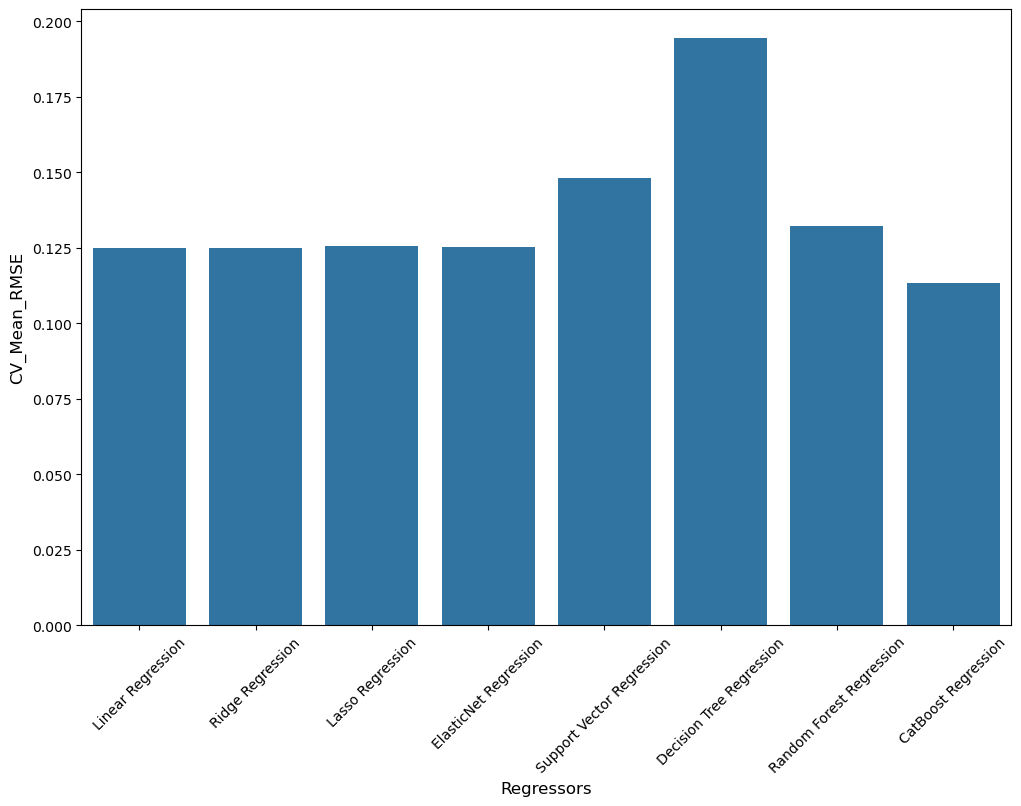

In [77]:
plt.figure(figsize = (12, 8))

# Sửa lại dòng vẽ barplot theo cú pháp chuẩn của Seaborn:
sns.barplot(x='Regressors', y='RMSE_mean', data=final_cv_score)

plt.xlabel('Regressors', fontsize = 12)
plt.ylabel('CV_Mean_RMSE', fontsize = 12)
plt.xticks(rotation = 45)
plt.show()

In [78]:
X_train,X_val,y_train,y_val = train_test_split(X_tr,y,test_size = 0.1,random_state=42)

In [79]:
cat = CatBoostRegressor(random_state=42,
                        verbose=0)
cat_model = cat.fit(X_train,y_train,
                     eval_set = (X_val,y_val))

In [80]:
def rmsle(y_true, y_pred):
    diffs = np.log(y_true + 1) - np.log(y_pred + 1) 
    squares = np.power(diffs, 2)
    err = np.sqrt(np.mean(squares)) 
    return err

In [81]:
cat_pred = cat_model.predict(X_val)
cat_score = rmsle(np.expm1(y_val), np.expm1(cat_pred))
cat_score

np.float64(0.09685687792190778)

In [82]:
feat_imp = cat_model.get_feature_importance(prettified=True)
feat_imp

,Feature Id,Importances
0,TotalSF,19.111463
1,OverallQual,10.666652
2,Neighborhood,7.570413
3,Total_Home_Quality,7.513567
4,Total_Bathrooms,3.122073
...,...,...
87,MiscFeature,0.009812
88,BsmtFinSF2,0.009152
89,LowQualFinSF,0.006078
90,pool,0.003384


# Hyperparameter Tuning

In [83]:
cat_model.get_all_params()

{'nan_mode': 'Min',
 'eval_metric': 'RMSE',
 'iterations': 1000,
 'sampling_frequency': 'PerTree',
 'leaf_estimation_method': 'Newton',
 'random_score_type': 'NormalWithModelSizeDecrease',
 'grow_policy': 'SymmetricTree',
 'penalties_coefficient': 1,
 'boosting_type': 'Plain',
 'model_shrink_mode': 'Constant',
 'feature_border_type': 'GreedyLogSum',
 'bayesian_matrix_reg': 0.10000000149011612,
 'eval_fraction': 0,
 'force_unit_auto_pair_weights': False,
 'l2_leaf_reg': 3,
 'random_strength': 1,
 'rsm': 1,
 'boost_from_average': True,
 'model_size_reg': 0.5,
 'pool_metainfo_options': {'tags': {}},
 'subsample': 0.800000011920929,
 'use_best_model': True,
 'random_seed': 42,
 'depth': 6,
 'posterior_sampling': False,
 'border_count': 254,
 'classes_count': 0,
 'auto_class_weights': 'None',
 'sparse_features_conflict_fraction': 0,
 'leaf_estimation_backtracking': 'AnyImprovement',
 'best_model_min_trees': 1,
 'model_shrink_rate': 0,
 'min_data_in_leaf': 1,
 'loss_function': 'RMSE',
 'lear

In [84]:
grid = {'iterations': [4000,6000],
        'learning_rate': [0.05, 0.005, 0.0005],
        'depth': [4, 6],
        'l2_leaf_reg': [1, 3, 5]}

final_model = CatBoostRegressor()
randomized_search_result = final_model.randomized_search(grid,
                                                   X = X_train,
                                                   y= y_train,
                                                   verbose = False,
                                                   plot=False)

0:	learn: 12.0164665	test: 12.0164190	best: 12.0164190 (0)	total: 2.48ms	remaining: 9.91s
1:	learn: 12.0104951	test: 12.0104476	best: 12.0104476 (1)	total: 4.31ms	remaining: 8.61s
2:	learn: 12.0045194	test: 12.0044682	best: 12.0044682 (2)	total: 5.56ms	remaining: 7.41s
3:	learn: 11.9985617	test: 11.9985173	best: 11.9985173 (3)	total: 6.82ms	remaining: 6.81s
4:	learn: 11.9925910	test: 11.9925432	best: 11.9925432 (4)	total: 8.25ms	remaining: 6.59s
5:	learn: 11.9866221	test: 11.9865718	best: 11.9865718 (5)	total: 10ms	remaining: 6.67s
6:	learn: 11.9806672	test: 11.9806155	best: 11.9806155 (6)	total: 11.8ms	remaining: 6.71s
7:	learn: 11.9747057	test: 11.9746646	best: 11.9746646 (7)	total: 13.4ms	remaining: 6.69s
8:	learn: 11.9687542	test: 11.9687074	best: 11.9687074 (8)	total: 15.2ms	remaining: 6.75s
9:	learn: 11.9628077	test: 11.9627606	best: 11.9627606 (9)	total: 17.2ms	remaining: 6.87s
10:	learn: 11.9568510	test: 11.9568068	best: 11.9568068 (10)	total: 19.3ms	remaining: 6.98s
11:	learn:

In [85]:
best_params = final_model.get_params()
print(best_params)

{'loss_function': 'RMSE', 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 6000}


In [98]:
params = {'iterations': 6000,
          'learning_rate': 0.05,
          'depth': 4,
          'l2_leaf_reg': 1,
          'eval_metric':'RMSE',
          'early_stopping_rounds': 200,
          'verbose': 200,
          'random_seed': 42}
         
cat_f = CatBoostRegressor(**params)
cat_model_f = cat_f.fit(X_train,y_train,
                     eval_set = (X_val,y_val),
                     verbose = False)

catf_pred = cat_model_f.predict(X_val)

In [99]:
catf_score = rmsle(np.expm1(y_val), np.expm1(catf_pred))
catf_score

np.float64(0.09724110020407745)

In [100]:
rmse(y_val, catf_pred)

np.float64(0.09724110020407745)

In [101]:
result = pd.Series(np.expm1(cat_model.predict(df_test)))
id_list = pd.Series(range(1461,2920))
submission9 = pd.concat([id_list,result],axis=1,keys=['Id','SalePrice'])
submission9

,Id,SalePrice
0,1461,121472.207979
1,1462,164594.923890
2,1463,189001.836336
3,1464,196385.854863
4,1465,186277.076853
...,...,...
1454,2915,88994.458470
1455,2916,78356.675774
1456,2917,151365.618937
1457,2918,127928.565003
